Let's check if the conductance of random lattices is similar or different. (Seed dependence)

In [62]:
%load_ext autoreload
%autoreload 2
import kwant
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from koala.lattice import Lattice
from alter_morph.hamiltonians import alt_hamiltonian, spectral_function
from alter_morph.lattice_utilities import alter_lattice_maker,add_contacts
from alter_morph.mean_field import hartree_fock
from alter_morph.kwant_utilities import Amorphous



# plotting
import matplotlib
import matplotlib.pyplot as plt

import koala.graph_utils


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [173]:
# create lattice
system_length = 10
seeds = 10
lattice_type = "voronoi"
n_fock_steps = 200


# set parameters, scan different values of J
t1 = 1  # orbital parallel neighbor hopping
t2 = 0.5  # orbital perpendicular neighbor hopping
J = 0.8  # Interaction strength
filling = 0.7  # filling of the lattice
theta_offset = 0  # angle of the lattice


lattices = []
for j in range(seeds):
    lattice = alter_lattice_maker(system_length, lattice_type)
    lattice = koala.graph_utils.cut_boundaries(lattice, [False, True])
    lattice = koala.graph_utils.remove_trailing_edges(lattice)
    lattices.append(lattice)

/var/folders/xb/6hhfs1vn32s_g5b9xk9fx8yh0000gn/T/ipykernel_69191/3733624626.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  im = ax.scatter(


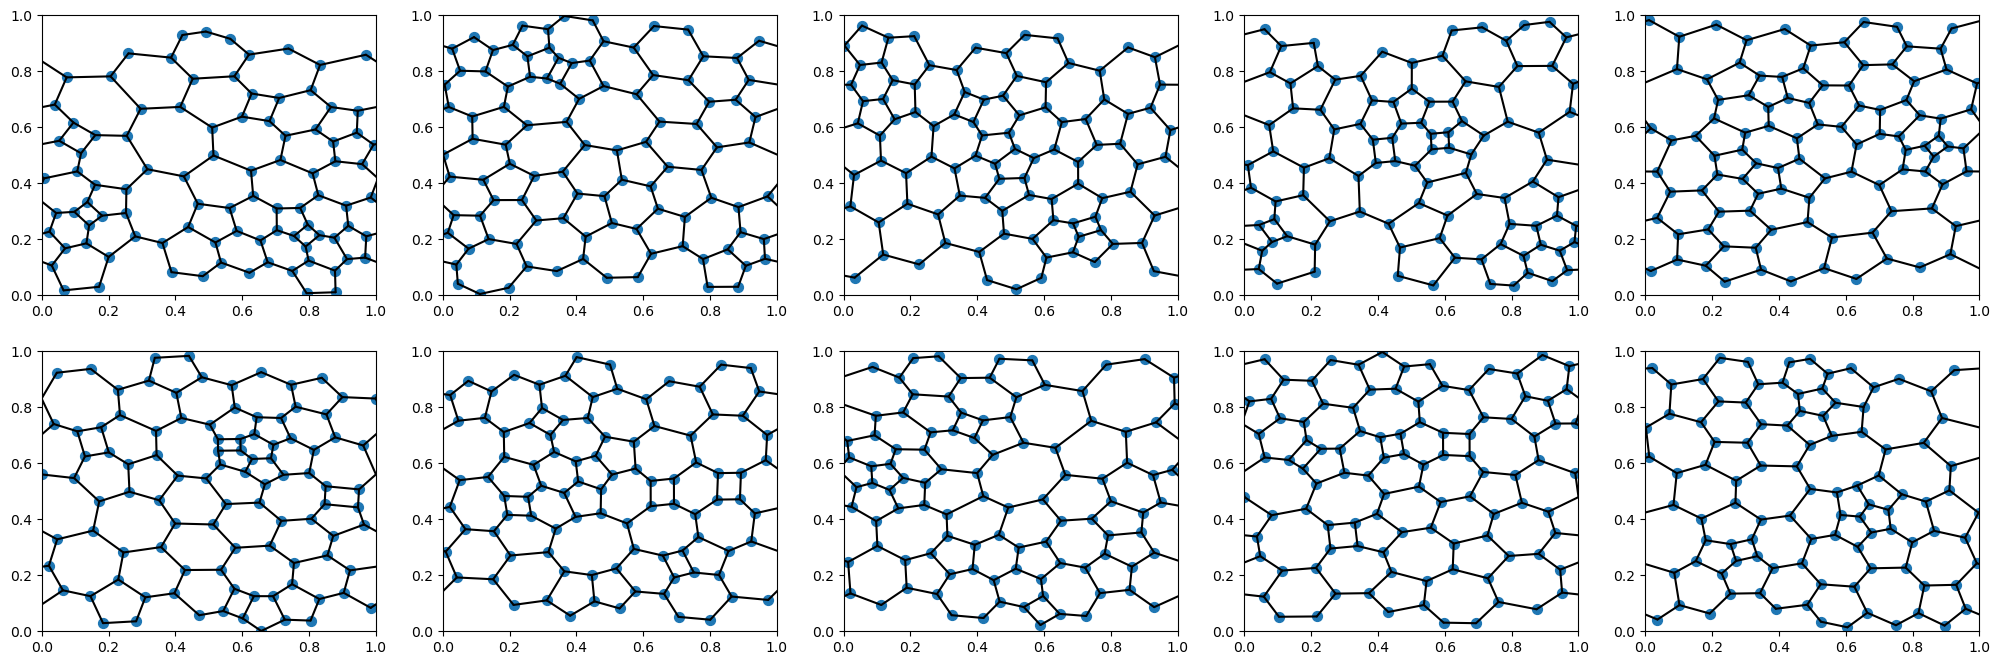

In [174]:
fig, axs = plt.subplots(2, seeds//2, figsize=(5*seeds//2, 8))
for j in range(seeds):
    ax = axs.flatten()[j]
    pl.plot_edges(lattices[j], ax=ax)
    im = ax.scatter(
        lattices[j].vertices.positions[:, 0],
        lattices[j].vertices.positions[:, 1],
        cmap="gist_stern_r",
        s=50,
        vmin=0,
        vmax=2,
    )

In [175]:
from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)

conds = []; ms = []; cond_spins = []; doss = []; spectrals = []

for j in range(seeds):

    lattice = lattices[j]

    initial_m = np.full(lattice.n_vertices, 1)  # initial magnetization
    initial_parameters = {"t1": t1,"t2": t2,"J": J,"filling": filling,"initial_m": initial_m,"theta_offset": theta_offset}
    m_values = hartree_fock(lattice, initial_parameters, n_fock_steps,tol_mdiff=1e-2)


    hamiltonian = alt_hamiltonian(
        lattice,
        t1,
        t2,
        J,
        m_values[-1],
    )

    energies, states = la.eigh(hamiltonian)
    fermi_energy = energies[int(filling*len(energies))] #better algorithm to get Fermi energy

    n_orbitals = 4
    lead_onsite = np.eye(n_orbitals)
    lead_coupling = np.eye(n_orbitals)

    contact_lattice, k_lattice, k_system, contact_vertices = (
        crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
    )
    kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
        contact_lattice, k_lattice, k_system, contact_vertices, lead_onsite, lead_coupling, np.diag([-1,-1,1,1])
    )

    k_system_f = k_system.finalized()
    smatrix = kwant.smatrix(k_system_f,energy=fermi_energy)
    g = np.array([[smatrix.transmission((1,j),(0,i)) for j in range(2)] for i in range(2)])
    
    broadening = 5e-2
    dos = np.sum(broadening/((energies-fermi_energy)**2 + broadening**2))/lattice.n_vertices
    
    #spectral function
    spectral = []
    spectral.append(spectral_function(lattice, energies, states, fermi_energy,local_projector=np.array([1, 0, 0, 0]),eta=broadening,n_k=50))
    spectral.append(spectral_function(lattice, energies, states, fermi_energy,local_projector=np.array([0, 1, 0, 0]),eta=broadening,n_k=50))
    spectral.append(spectral_function(lattice, energies, states, fermi_energy,local_projector=np.array([0, 0, 1, 0]),eta=broadening,n_k=50))
    spectral.append(spectral_function(lattice, energies, states, fermi_energy,local_projector=np.array([0, 0, 0, 1]),eta=broadening,n_k=50))


    conds.append(g[0,0]+g[1,1])
    cond_spins.append(g[0,0]-g[1,1])
    ms.append(m_values[-1])
    doss.append(dos)
    spectrals.append(spectral)

conds = np.array(conds)
cond_spins = np.array(cond_spins)
#ms = np.array(ms)
doss = np.array(doss)

Avg:1.20, diff: 0.009421:  28%|██▊       | 56/200 [00:02<00:06, 22.43it/s]


avg. magnetization  1.1965860865170392 0.0015715201019676215
dos  1.000990236023179 0.13669637766230325


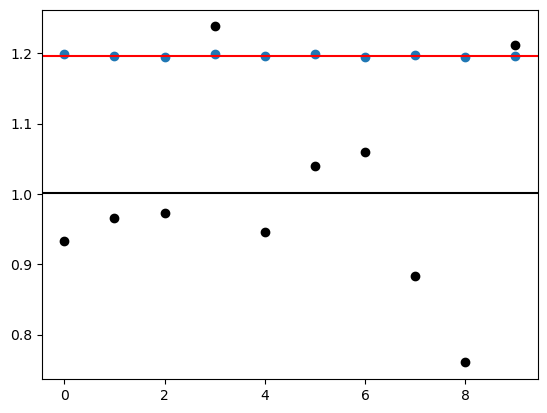

In [176]:
mavgs = [np.mean(x) for x in ms]

plt.plot(mavgs, "o")
plt.axhline(np.mean(mavgs), color="red")

plt.plot(doss, "ko")
plt.axhline(doss.mean(), color="k")

print('avg. magnetization ', np.mean(mavgs), np.std(mavgs))
print('dos ', np.mean(doss), np.std(doss))

conductance mean + std,:  0.5585184216350032 0.3265325727556636
spin conductance mean + std,:  0.4474325332732084 0.35273421399363364
quotient:  0.7572054150564502 0.2662735629171179


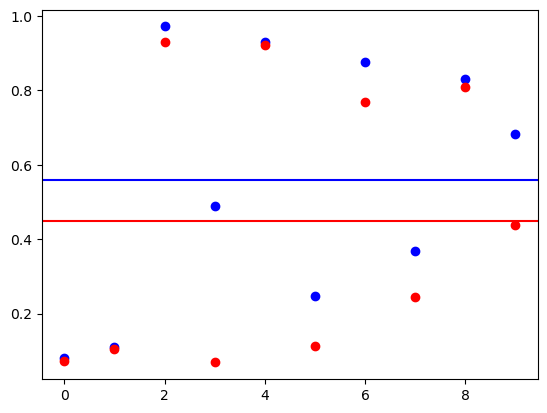

In [177]:
plt.plot(conds, "bo",label='conductance')
plt.plot(cond_spins, "ro",label='conductance')
plt.axhline(conds.mean(), color="b")
plt.axhline(cond_spins.mean(), color="r")

print('conductance mean + std,: ',conds.mean(), conds.std())
print('spin conductance mean + std,: ',cond_spins.mean(), cond_spins.std())
print('quotient: ', np.mean(cond_spins/conds), np.std(cond_spins/conds))

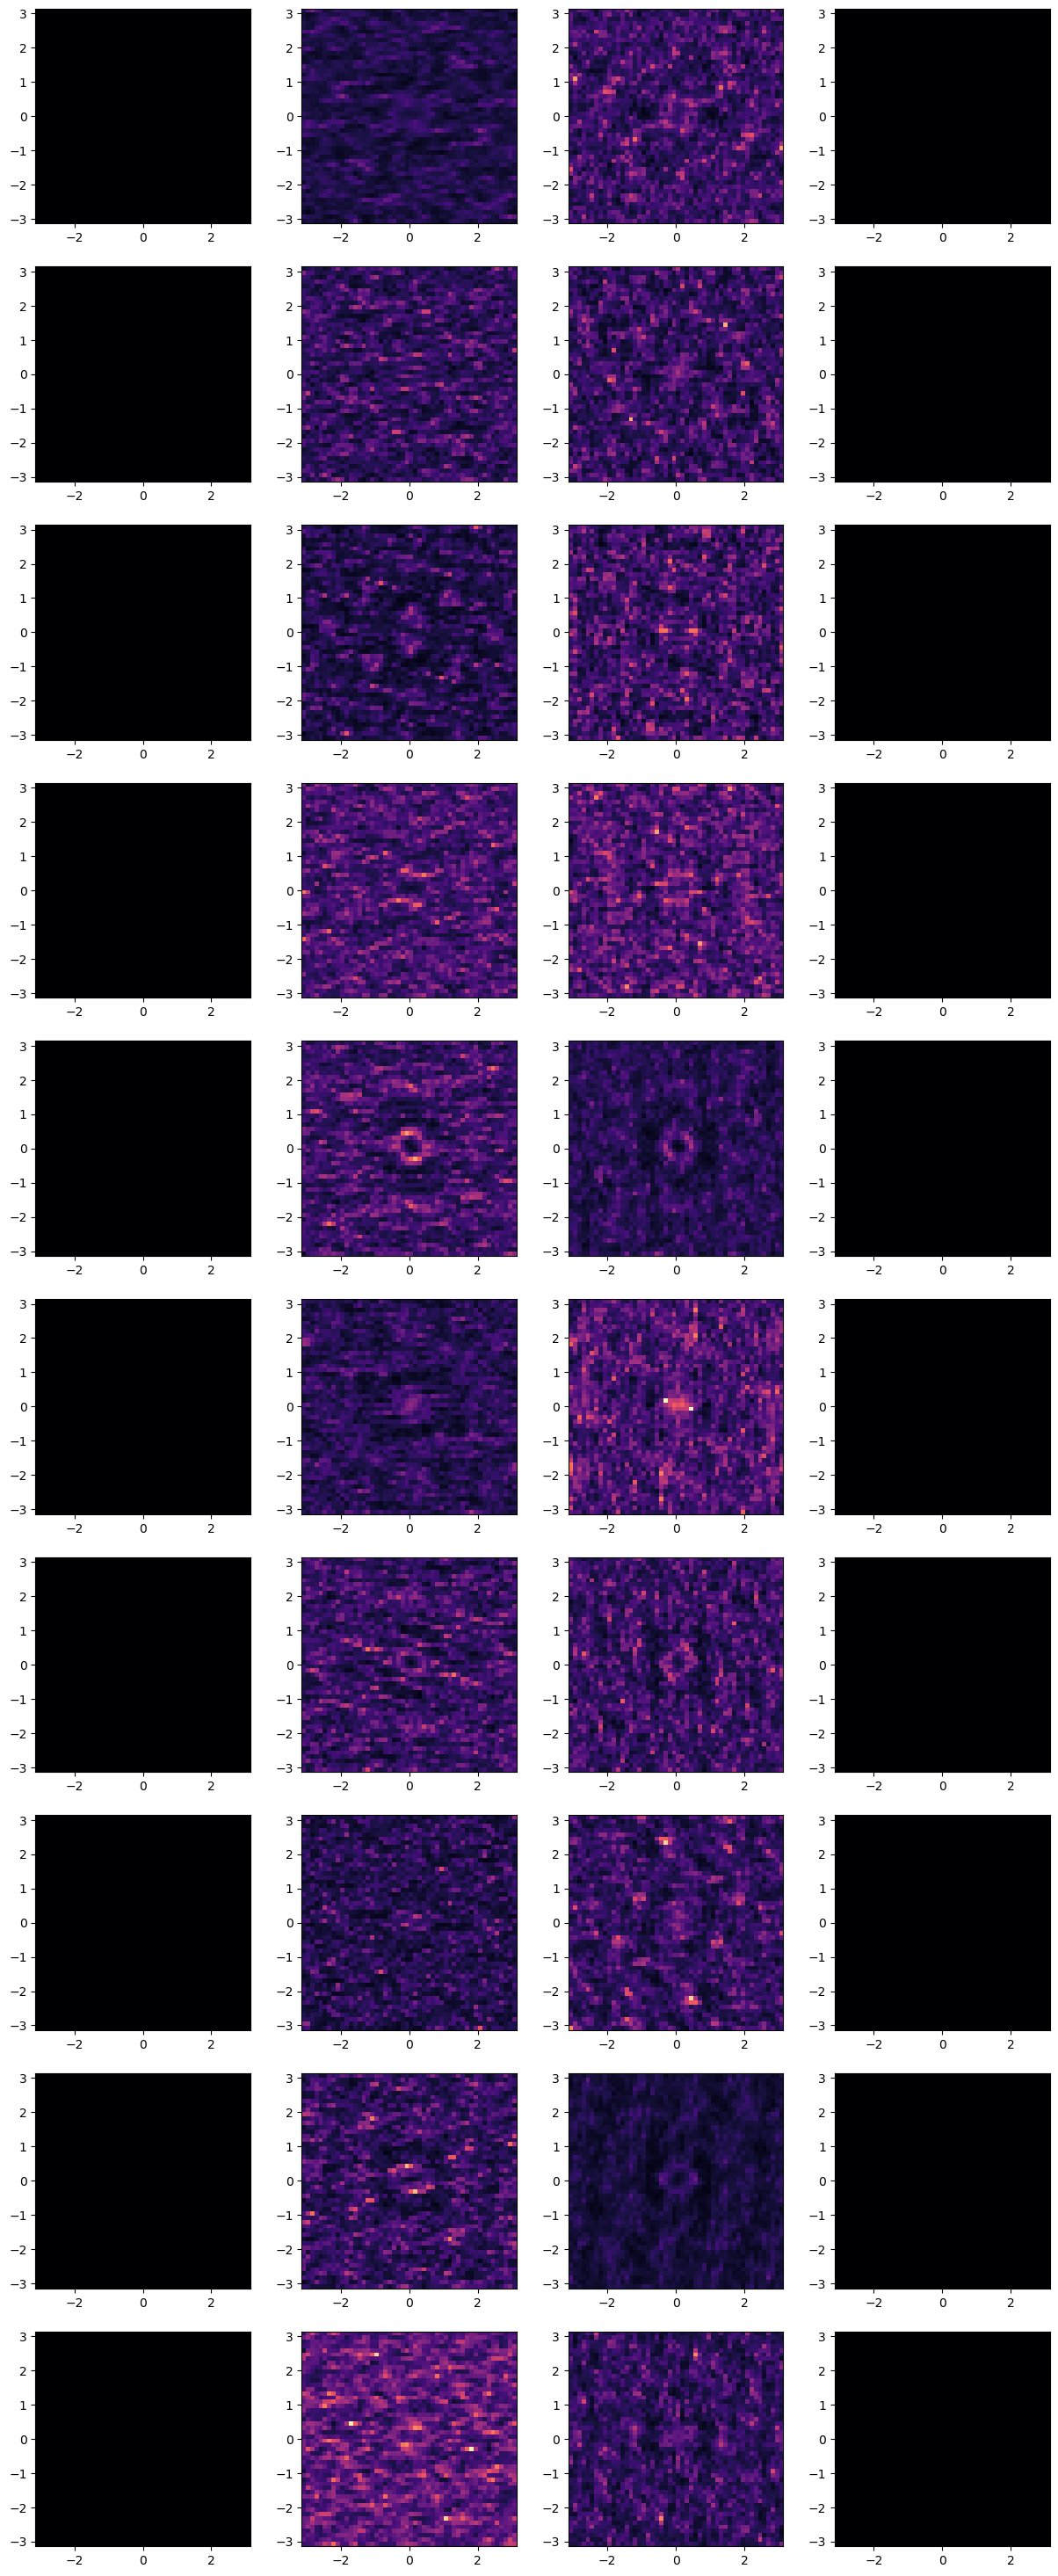

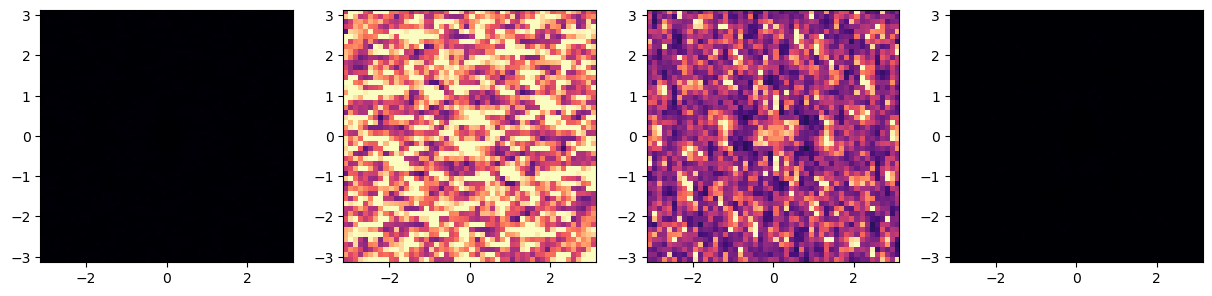

In [178]:
fig, axs = plt.subplots(seeds, 4,figsize=(15, 15*seeds/4))

vmax = np.max(np.abs(spectrals))

for j in range(seeds):
    for i in range(4):
        #print(np.max(-np.imag(spectrals[j][i])))
        ax = axs[j, i]
        ax.imshow(-np.imag(spectrals[j][i]), cmap="magma", origin="lower", extent=[-np.pi, np.pi, -np.pi, np.pi],vmin=0,vmax=vmax,)
        #ax.set_title(f"Spin {i}")

fig, axs = plt.subplots(1, 4,figsize=(15, 15/4))
mean_spec = np.mean(-np.imag(spectrals), axis=0)
vmax = np.max(mean_spec.max())
for i in range(4):
    ax = axs[i]
    ax.imshow(-np.imag(spectrals[j][i]), cmap="magma", origin="lower", extent=[-np.pi, np.pi, -np.pi, np.pi],vmin=0,vmax=vmax,)

-1.3870743138856514


TypeError: unsupported operand type(s) for *: 'numpy.ufunc' and 'float'

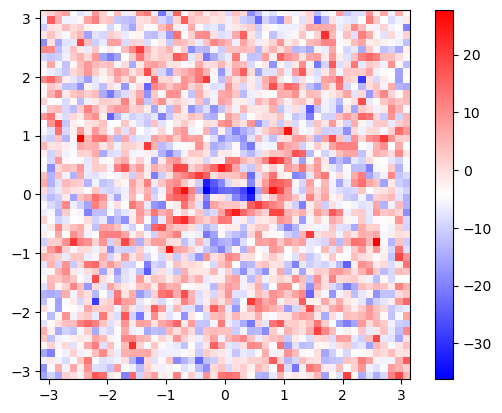

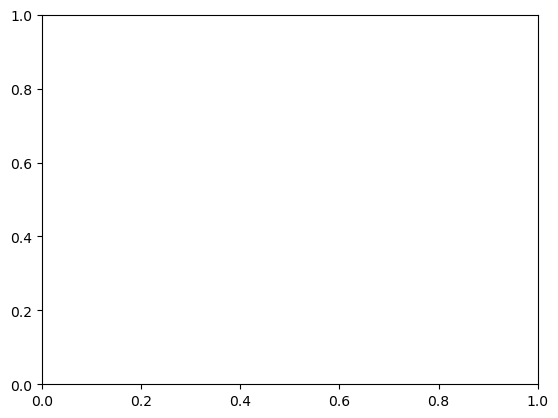

In [ ]:
avg_spin_spectra = np.einsum('b,bxy->xy',np.array([1,1,-1,-1]),mean_spec)

fig, ax = plt.subplots(1, 1)
im=ax.imshow(avg_spin_spectra, cmap="bwr", origin="lower", extent=[-np.pi, np.pi, -np.pi, np.pi])
plt.colorbar(im)

print(avg_spin_spectra.mean())

x,y = np.meshgrid(np.linspace(-np.pi,np.pi,50),np.linspace(-np.pi,np.pi,50))
weight = np.cos(x) - np.cos(y)
#weight = np.arctan2

fig, ax = plt.subplots(1, 1)
im=ax.imshow(weight*avg_spin_spectra, cmap="bwr", origin="lower", extent=[-np.pi, np.pi, -np.pi, np.pi])
plt.colorbar(im)

print(np.sum(weight*avg_spin_spectra))



(50, 50, 396) (50, 50, 396)
False
0.7526001930236816
0.3872849941253662


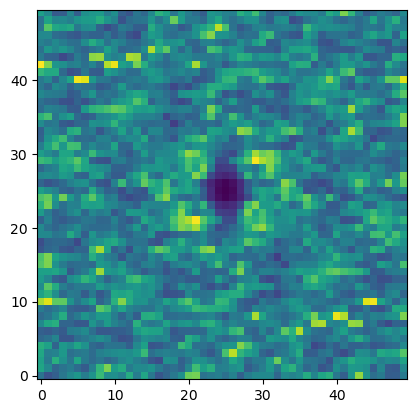

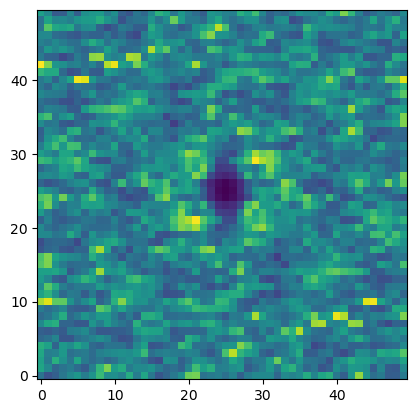

In [259]:
def spectral_function_reshape(
    lattice: Lattice,
    energies: np.ndarray,
    states: np.ndarray,
    omega: float,
    eta=1e-6,
    local_projector=np.array([1, 1, 0, 0]),
    n_k=None,
):
    """
    Calculates the spectral function for a given set of energies
    and states, projected onto a local set of spin and orbital states

    Args:
        lattice (Lattice): The lattice
        energies (np.ndarray): The eigenvalues of the Hamiltonian
        states (np.ndarray): The eigenvectors of the Hamiltonian
        omega (float): The energy to calculate the spectral function at
        eta (float, optional): The broadening parameter for the spectral function. Defaults to 1e-6.
        local_projector (np.ndarray, optional): The local set of spin/orbitals to project the states onto. Defaults to np.array([1, 1, 0, 0]).
        n_k (int, optional): The number of k points to sample, if None will be sqrt(n_vertices). Defaults to None.

    Returns:
        np.ndarray: The spectral function
    """

    if n_k is None:
        n_k = np.sqrt(lattice.n_vertices).astype(int)
        # print(n_k)

    positions = lattice.vertices.positions
    n_vertices = lattice.n_vertices
    n_orbitals = len(local_projector)

    ########################
    #approach based on reshaping
    states = states.reshape(n_vertices,n_orbitals,n_vertices*n_orbitals) #.shape=(n_vertices,n_orbitals,n_vertices*n_orbitals)

    k_vals = np.arange(-n_k // 2, n_k // 2) * 2 * np.pi
    ks = np.array(np.meshgrid(k_vals, k_vals)) #.shape=(2,ky,kx)

    phase = np.exp(1j * np.einsum('ryx,nr->yxn',ks,positions)) #.shape=(ky,kx,n_vertices)
    k_states = np.einsum('yxn,noh->yxoh',phase,states) #.shape=(ky,kx,n_orbitals,n_vertices*n_orbitals)
    k_densities = np.abs(k_states)**2 #.shape=(ky,kx,n_orbitals,n_vertices*n_orbitals)

    Ak = eta/np.pi / ((energies - omega)**2 + eta**2) / n_vertices / n_orbitals #.shape=(n_vertices*n_orbitals)
    Ako = np.einsum('yxoh,h->yxo',k_densities,Ak) #.shape=(ky,kx,n_orbitals)
    spectral_function = np.einsum('yxo,o->yx',Ako,local_projector) #.shape=(ky,kx)
    
    return spectral_function


def spectral_function_VL(
    lattice: Lattice,
    energies: np.ndarray,
    states: np.ndarray,
    omega: float,
    eta=1e-6,
    local_projector=np.array([1, 1, 0, 0]),
    n_k=None,
):
    """
    Calculates the spectral function for a given set of energies
    and states, projected onto a local set of spin and orbital states

    Args:
        lattice (Lattice): The lattice
        energies (np.ndarray): The eigenvalues of the Hamiltonian
        states (np.ndarray): The eigenvectors of the Hamiltonian
        omega (float): The energy to calculate the spectral function at
        eta (float, optional): The broadening parameter for the spectral function. Defaults to 1e-6.
        local_projector (np.ndarray, optional): The local set of spin/orbitals to project the states onto. Defaults to np.array([1, 1, 0, 0]).
        n_k (int, optional): The number of k points to sample, if None will be sqrt(n_vertices). Defaults to None.

    Returns:
        np.ndarray: The spectral function
    """

    if n_k is None:
        n_k = np.sqrt(lattice.n_vertices).astype(int)
        # print(n_k)

    positions = lattice.vertices.positions
    n_vertices = lattice.n_vertices
    n_orbitals = len(local_projector)


    #######################
    k_vals = np.arange(-n_k // 2, n_k // 2) * 2 * np.pi
    ks = np.array(np.meshgrid(k_vals, k_vals)) #.shape=(2,ky,kx)

    Ak = eta/np.pi / ((energies - omega)**2 + eta**2) / n_vertices / n_orbitals #.shape=(n_vertices*n_orbitals)

    phase = np.exp(1j * np.einsum('ryx,nr->xyn',ks,positions)) #.shape=(ky,kx,n_vertices)
    
    #1D kron of last axis
    kron = np.einsum('ayxn,ao->yxno',phase[np.newaxis],local_projector[np.newaxis]).reshape(*phase.shape[:-1],phase.shape[-1]*local_projector.shape[-1])
    projected_k_state = np.einsum('hh,yxh->yxh',states,kron)
    projected_k_density = np.abs(projected_k_state)**2

    spectral_function = np.einsum('h,yxh->yx',Ak,projected_k_density)

    #return spectral_function


    resolvent = states * Ak @ states.conj().T
    spectral_function = np.zeros((len(k_vals), len(k_vals)), dtype=complex)

    k_states = np.zeros((len(k_vals), len(k_vals), n_vertices), dtype=complex)
    projected_states = np.zeros((len(k_vals), len(k_vals), n_vertices*n_orbitals), dtype=complex)


    for idx, kx in enumerate(k_vals):
        for idy, ky in enumerate(k_vals):
            #substituted
            #k_state = np.exp(1j * (kx * positions[:, 0] + ky * positions[:, 1]))
            #k_states[idx, idy] = k_state
            k_state = phase[idx, idy]

            #substituted
            projected_state = np.kron(k_state, local_projector)
            projected_states[idx, idy] = projected_state
            #projected_state = projected_k_state[idx, idy]

            spectral_function[idx, idy] = (
                projected_state.conj() @ resolvent @ projected_state
            )
    
    #print((k_states==phase).all()) #true
    print(projected_states.shape,projected_k_state.shape) #true
    #print((projected_states==projected_k_state).all()) #not the same

    return np.abs(spectral_function)

import time

t0 = time.time()
#x1 = spectral_function_reshape(lattice, energies, states, fermi_energy,local_projector=np.array([1, 0, 0, 0]),eta=broadening,n_k=50) 
x1 = spectral_function_VL(lattice, energies, states, fermi_energy,local_projector=np.array([1, 0, 0, 0]),eta=broadening,n_k=50) 
t1 = time.time()
print(t1-t0)
x2 = spectral_function(lattice, energies, states, fermi_energy,local_projector=np.array([1, 0, 0, 0]),eta=broadening,n_k=50)
x2 = x2/np.pi/lattice.n_vertices
print(time.time()-t1)

plt.imshow(x1,origin='lower')
plt.show()
plt.imshow(-np.imag(x2),origin='lower')

In [199]:
x = np.kron(np.arange(10),np.ones(4))

print(x)
x = np.reshape(x,(10,4))
print(x)


[0. 0. 0. 0. 1. 1. 1. 1. 2. 2. 2. 2. 3. 3. 3. 3. 4. 4. 4. 4. 5. 5. 5. 5.
 6. 6. 6. 6. 7. 7. 7. 7. 8. 8. 8. 8. 9. 9. 9. 9.]
[[0. 0. 0. 0.]
 [1. 1. 1. 1.]
 [2. 2. 2. 2.]
 [3. 3. 3. 3.]
 [4. 4. 4. 4.]
 [5. 5. 5. 5.]
 [6. 6. 6. 6.]
 [7. 7. 7. 7.]
 [8. 8. 8. 8.]
 [9. 9. 9. 9.]]


In [225]:
x = np.array([[1,1,],[2,2,]])
y = np.array([1,2,3])

np.einsum('jab,jk->abk',x[np.newaxis],y[np.newaxis]).reshape((*x.shape[:-1],x.shape[-1]*y.shape[0]))

array([[1, 2, 3, 1, 2, 3],
       [2, 4, 6, 2, 4, 6]])